<a href="https://colab.research.google.com/github/rprieto2809/AIB1/blob/master/cubo_olap_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌟 Modelo en Estrella, Cubo OLAP y Visualización con PySpark

Este notebook carga el **modelo en estrella real desde SQL Server** (exportado a CSV en GitHub), construye un **cubo OLAP** con PySpark y genera **gráficos** para visualizar cada operación analítica.

## Fuente de datos
📦 Repositorio GitHub: https://github.com/rprieto2809/CUBOS-CSV

## Contenido
| Celda | Contenido |
|-------|-----------|
| 1 | Instalación y configuración |
| 2 | Descarga de CSVs desde GitHub |
| 3 | Carga de dimensiones y hechos |
| 4 | Verificación de datos |
| 5 | Construcción del cubo |
| 6 | Roll-up + gráfico de líneas |
| 7 | Drill-down + gráfico de barras |
| 8 | Slice + gráfico de barras apiladas |
| 9 | Dice + gráfico de barras agrupadas |
| 10 | Pivot + Heatmap |
| 11 | Cuota de mercado + gráfico de tarta |
| 12 | Window Functions + gráfico de área |
| 13 | Resumen final |


## ⚙️ Celda 1: Instalación y configuración

In [ ]:
!pip install pyspark --quiet

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Estilo visual uniforme para todos los gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORES = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

spark = SparkSession.builder \
    .appName('CuboOLAP_Graficos') \
    .config('spark.sql.repl.eagerEval.enabled', True) \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

print('✅ PySpark y Matplotlib listos')
print(f'   Spark: {spark.version}')

✅ PySpark y Matplotlib listos
   Spark: 4.0.2


## 📥 Celda 2: Descarga de CSVs desde GitHub

In [ ]:
import urllib.request, os

BASE_URL = 'https://raw.githubusercontent.com/rprieto2809/CUBOS-CSV/main/'
archivos = ['D_Producto.csv','D_Sucursal.csv','D_Cliente.csv',
            'D_Vendedor.csv','D_Tiempo.csv','H_Ventas.csv']

os.makedirs('/tmp/cubos', exist_ok=True)
for f in archivos:
    urllib.request.urlretrieve(BASE_URL + f, f'/tmp/cubos/{f}')
    print(f'✅ {f}')

print('\n📂 Todos los archivos descargados en /tmp/cubos/')

✅ D_Producto.csv
✅ D_Sucursal.csv
✅ D_Cliente.csv
✅ D_Vendedor.csv
✅ D_Tiempo.csv
✅ H_Ventas.csv

📂 Todos los archivos descargados en /tmp/cubos/


## 🏗️ Celda 3: Carga de dimensiones y tabla de hechos

In [ ]:
D_Producto = spark.read.csv('/tmp/cubos/D_Producto.csv', header=True, inferSchema=True)
D_Sucursal = spark.read.csv('/tmp/cubos/D_Sucursal.csv', header=True, inferSchema=True)
D_Cliente  = spark.read.csv('/tmp/cubos/D_Cliente.csv',  header=True, inferSchema=True)
D_Vendedor = spark.read.csv('/tmp/cubos/D_Vendedor.csv', header=True, inferSchema=True)
D_Tiempo   = spark.read.csv('/tmp/cubos/D_Tiempo.csv',   header=True, inferSchema=True)
H_Ventas   = spark.read.csv('/tmp/cubos/H_Ventas.csv',   header=True, inferSchema=True)

print('✅ Tablas cargadas:')
for nombre, df in [('D_Producto',D_Producto),('D_Sucursal',D_Sucursal),
                   ('D_Cliente',D_Cliente),('D_Vendedor',D_Vendedor),
                   ('D_Tiempo',D_Tiempo),('H_Ventas',H_Ventas)]:
    print(f'   {nombre:12} → {df.count()} registros')

✅ Tablas cargadas:
   D_Producto   → 15 registros
   D_Sucursal   → 20 registros
   D_Cliente    → 100 registros
   D_Vendedor   → 30 registros
   D_Tiempo     → 181 registros
   H_Ventas     → 1000 registros


## 🔎 Celda 4: Verificación de los datos

In [ ]:
print('── D_Producto ──')
D_Producto.show(3, truncate=40)
print('── D_Sucursal ──')
D_Sucursal.show(3, truncate=40)
print('── D_Tiempo ──')
D_Tiempo.show(3)
print('── H_Ventas ──')
H_Ventas.show(5)

── D_Producto ──
+----------+--------------+--------------+--------------------------+--------------+-----------------+
|IdProducto|CodigoProducto|NombreProducto|       DescripcionProducto|PrecioUnitario|CategoriaProducto|
+----------+--------------+--------------+--------------------------+--------------+-----------------+
|         1|         PROD1|    Producto 1|Descripcion del producto 1|         67.97|      Categoria 2|
|         2|         PROD2|    Producto 2|Descripcion del producto 2|         32.98|      Categoria 3|
|         3|         PROD3|    Producto 3|Descripcion del producto 3|          7.15|      Categoria 4|
+----------+--------------+--------------+--------------------------+--------------+-----------------+
only showing top 3 rows
── D_Sucursal ──
+----------+--------------+--------------+-----------------+--------------+------------+
|IdSucursal|CodigoSucursal|NombreSucursal|DireccionSucursal|CiudadSucursal|PaisSucursal|
+----------+--------------+--------------+-

## 🔗 Celda 5: Construcción del Cubo
Unimos la tabla de hechos con todas las dimensiones para obtener un único DataFrame desnormalizado listo para analizar desde cualquier perspectiva.

In [ ]:
Cubo_Ventas = H_Ventas \
    .join(D_Producto, on='IdProducto', how='left') \
    .join(D_Sucursal, on='IdSucursal', how='left') \
    .join(D_Cliente,  on='IdCliente',  how='left') \
    .join(D_Vendedor, on='IdVendedor', how='left') \
    .join(D_Tiempo,   on='IdTiempo',   how='left') \
    .select(
        'IdVenta',
        'Fecha','Anio','Trimestre','Semestre','Mes','Dia',
        'NombreProducto','CategoriaProducto','PrecioUnitario',
        'NombreSucursal','CiudadSucursal','PaisSucursal',
        F.concat(F.col('NombreCliente'), F.lit(' '), F.col('ApellidoCliente')).alias('NombreCliente'),
        'CiudadCliente','PaisCliente',
        F.concat(F.col('NombreVendedor'), F.lit(' '), F.col('ApellidoVendedor')).alias('NombreVendedor'),
        'CiudadVendedor','PaisVendedor',
        'CantidadVenta','TotalVenta'
    )

Cubo_Ventas.createOrReplaceTempView('Cubo_Ventas')
print(f'✅ Cubo construido: {Cubo_Ventas.count()} filas × {len(Cubo_Ventas.columns)} columnas')
Cubo_Ventas.show(3, truncate=30)

✅ Cubo construido: 1000 filas × 21 columnas
+-------+----------+----+---------+--------+---+---+--------------+-----------------+--------------+--------------+--------------+------------+----------------------+-------------+-----------+-----------------------+--------------+------------+-------------+----------+
|IdVenta|     Fecha|Anio|Trimestre|Semestre|Mes|Dia|NombreProducto|CategoriaProducto|PrecioUnitario|NombreSucursal|CiudadSucursal|PaisSucursal|         NombreCliente|CiudadCliente|PaisCliente|         NombreVendedor|CiudadVendedor|PaisVendedor|CantidadVenta|TotalVenta|
+-------+----------+----+---------+--------+---+---+--------------+-----------------+--------------+--------------+--------------+------------+----------------------+-------------+-----------+-----------------------+--------------+------------+-------------+----------+
|      1|2022-06-28|2022|        2|       1|  6| 28|    Producto 5|      Categoria 1|         12.47|    Sucursal 9|     Ciudad 10|      Pais 5|Cli

## 🔺 Celda 6: ROLL-UP + Gráfico de Líneas

**Roll-up** = subir en la jerarquía temporal agregando más datos (día → mes → trimestre → año).

**Gráfico de líneas**: ideal para mostrar **evolución temporal**. Permite ver tendencias, picos y caídas a lo largo del tiempo. Es el gráfico más natural para el resultado de un roll-up temporal.

+----+---+-----------+--------+
|Anio|Mes|TotalVentas|Unidades|
+----+---+-----------+--------+
|2022|  1|   40421.78|     759|
|2022|  2|   58111.27|     994|
|2022|  3|   53553.48|     899|
|2022|  4|   59649.12|    1045|
|2022|  5|   65990.15|    1193|
|2022|  6|   54823.84|     921|
+----+---+-----------+--------+



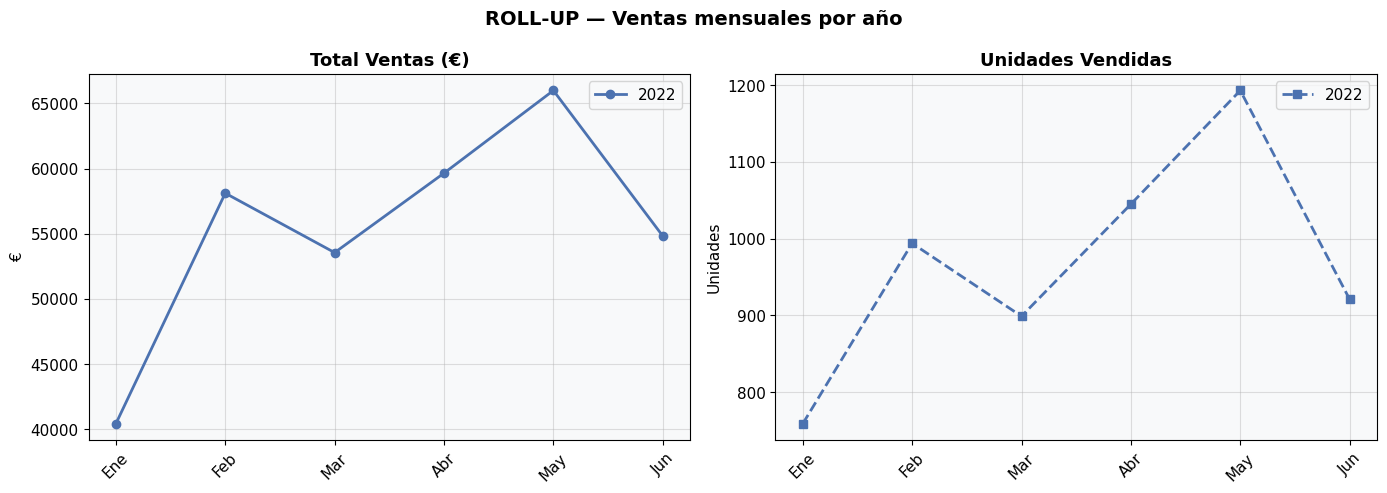

💡 El gráfico de líneas es perfecto para roll-up temporal: muestra la tendencia mes a mes y permite comparar años de un vistazo.


In [ ]:
# ── Consulta OLAP ──
ventas_mes = spark.sql('''
    SELECT Anio, Mes,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas,
           SUM(CantidadVenta)        AS Unidades
    FROM Cubo_Ventas
    GROUP BY Anio, Mes
    ORDER BY Anio, Mes
''')
ventas_mes.show()

# ── Gráfico de líneas ──
df = ventas_mes.toPandas()
anios = sorted(df['Anio'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROLL-UP — Ventas mensuales por año', fontsize=14, fontweight='bold')

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for i, anio in enumerate(anios):
    datos = df[df['Anio'] == anio].sort_values('Mes')
    etiq  = [meses[m-1] for m in datos['Mes']]

    # Ventas €
    axes[0].plot(etiq, datos['TotalVentas'], marker='o', label=str(anio),
                 color=COLORES[i], linewidth=2)
    # Unidades
    axes[1].plot(etiq, datos['Unidades'], marker='s', label=str(anio),
                 color=COLORES[i], linewidth=2, linestyle='--')

axes[0].set_title('Total Ventas (€)')
axes[0].set_ylabel('€')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Unidades Vendidas')
axes[1].set_ylabel('Unidades')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('💡 El gráfico de líneas es perfecto para roll-up temporal: muestra la tendencia mes a mes y permite comparar años de un vistazo.')

## 🔻 Celda 7: DRILL-DOWN + Gráfico de Barras

**Drill-down** = bajar en la jerarquía geográfica (país → ciudad → sucursal).

**Gráfico de barras**: ideal para **comparar categorías**. Cuando hacemos drill-down obtenemos un listado de elementos (sucursales, ciudades) que queremos comparar entre sí. La altura de cada barra hace la comparación inmediata y visual.

+--------------+--------------+------------+-----------+--------+
|NombreSucursal|CiudadSucursal|PaisSucursal|TotalVentas|Unidades|
+--------------+--------------+------------+-----------+--------+
|    Sucursal 1|      Ciudad 2|      Pais 2|   23561.65|     373|
|    Sucursal 6|      Ciudad 7|      Pais 2|   22421.89|     355|
|   Sucursal 13|      Ciudad 4|      Pais 4|    20244.2|     330|
|   Sucursal 17|      Ciudad 8|      Pais 3|    19839.8|     349|
|   Sucursal 12|      Ciudad 3|      Pais 3|   19154.61|     295|
|   Sucursal 11|      Ciudad 2|      Pais 2|   18685.39|     318|
|   Sucursal 15|      Ciudad 6|      Pais 1|   17968.64|     315|
|    Sucursal 8|      Ciudad 9|      Pais 4|   17544.88|     310|
|    Sucursal 3|      Ciudad 4|      Pais 4|   16987.01|     311|
|   Sucursal 14|      Ciudad 5|      Pais 5|   16634.67|     339|
|    Sucursal 4|      Ciudad 5|      Pais 5|   15929.61|     304|
|   Sucursal 16|      Ciudad 7|      Pais 2|   15727.14|     266|
|   Sucurs

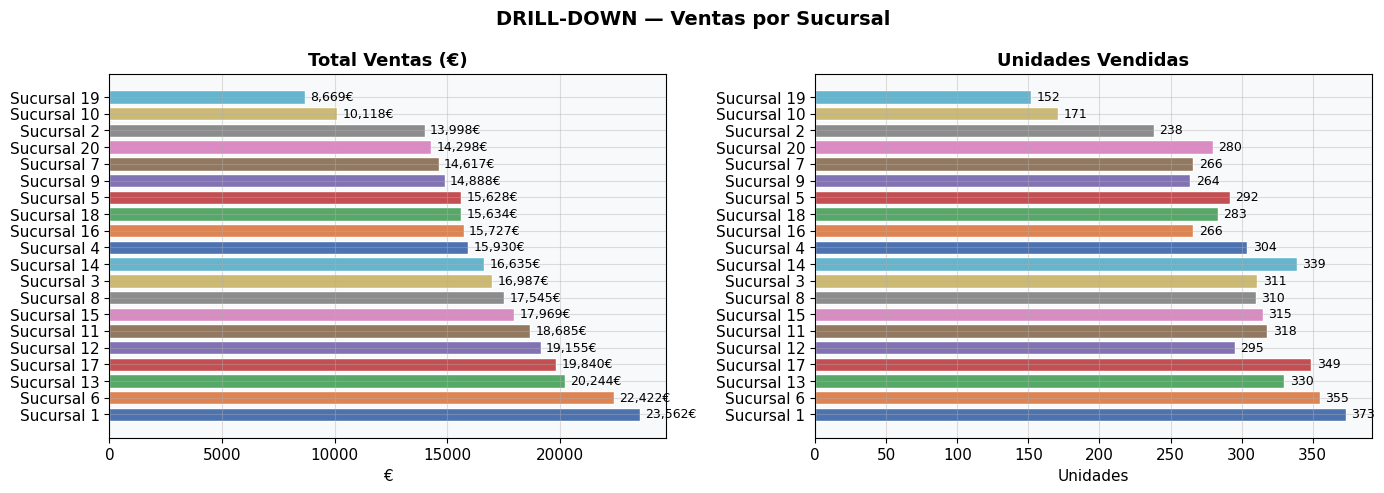

💡 El gráfico de barras es el más adecuado para drill-down: compara valores entre sucursales/ciudades de forma directa e inmediata.


In [ ]:
# ── Consulta OLAP ──
ventas_sucursal = spark.sql('''
    SELECT NombreSucursal, CiudadSucursal, PaisSucursal,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas,
           SUM(CantidadVenta)        AS Unidades
    FROM Cubo_Ventas
    GROUP BY NombreSucursal, CiudadSucursal, PaisSucursal
    ORDER BY TotalVentas DESC
''')
ventas_sucursal.show()

# ── Gráfico de barras ──
df = ventas_sucursal.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DRILL-DOWN — Ventas por Sucursal', fontsize=14, fontweight='bold')

# Barras horizontales — más legibles con etiquetas largas
bars = axes[0].barh(df['NombreSucursal'], df['TotalVentas'],
                    color=COLORES[:len(df)], edgecolor='white')
axes[0].set_title('Total Ventas (€)')
axes[0].set_xlabel('€')
for bar, val in zip(bars, df['TotalVentas']):
    axes[0].text(bar.get_width() + max(df['TotalVentas'])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}€', va='center', fontsize=9)

bars2 = axes[1].barh(df['NombreSucursal'], df['Unidades'],
                     color=COLORES[:len(df)], edgecolor='white')
axes[1].set_title('Unidades Vendidas')
axes[1].set_xlabel('Unidades')
for bar, val in zip(bars2, df['Unidades']):
    axes[1].text(bar.get_width() + max(df['Unidades'])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 El gráfico de barras es el más adecuado para drill-down: compara valores entre sucursales/ciudades de forma directa e inmediata.')

## 🔪 Celda 8: SLICE + Barras Apiladas

**Slice** = fijamos una dimensión y analizamos el resto (ej: solo el primer trimestre).

**Barras apiladas**: ideales para mostrar **composición y parte del todo**. Después de un slice queremos ver cómo se distribuyen las ventas dentro del subconjunto. Las barras apiladas muestran el total y la composición interna al mismo tiempo.

🔪 SLICE aplicado: Trimestre = Q1
+--------------+-----------------+-----------+
|NombreSucursal|CategoriaProducto|TotalVentas|
+--------------+-----------------+-----------+
|    Sucursal 1|      Categoria 5|    1767.79|
|    Sucursal 1|      Categoria 1|     2589.7|
|    Sucursal 1|      Categoria 4|     612.59|
|    Sucursal 1|      Categoria 2|    3295.62|
|    Sucursal 1|      Categoria 3|    1325.12|
|   Sucursal 10|      Categoria 4|     673.97|
|   Sucursal 10|      Categoria 1|    1843.84|
|   Sucursal 10|      Categoria 3|      360.0|
|   Sucursal 10|      Categoria 2|    2106.29|
|   Sucursal 10|      Categoria 5|    1415.43|
|   Sucursal 11|      Categoria 4|    2475.26|
|   Sucursal 11|      Categoria 1|     137.17|
|   Sucursal 11|      Categoria 5|    1138.31|
|   Sucursal 11|      Categoria 2|     1682.7|
|   Sucursal 11|      Categoria 3|     986.14|
|   Sucursal 12|      Categoria 5|    2381.34|
|   Sucursal 12|      Categoria 2|    2620.09|
|   Sucursal 12|      Categ

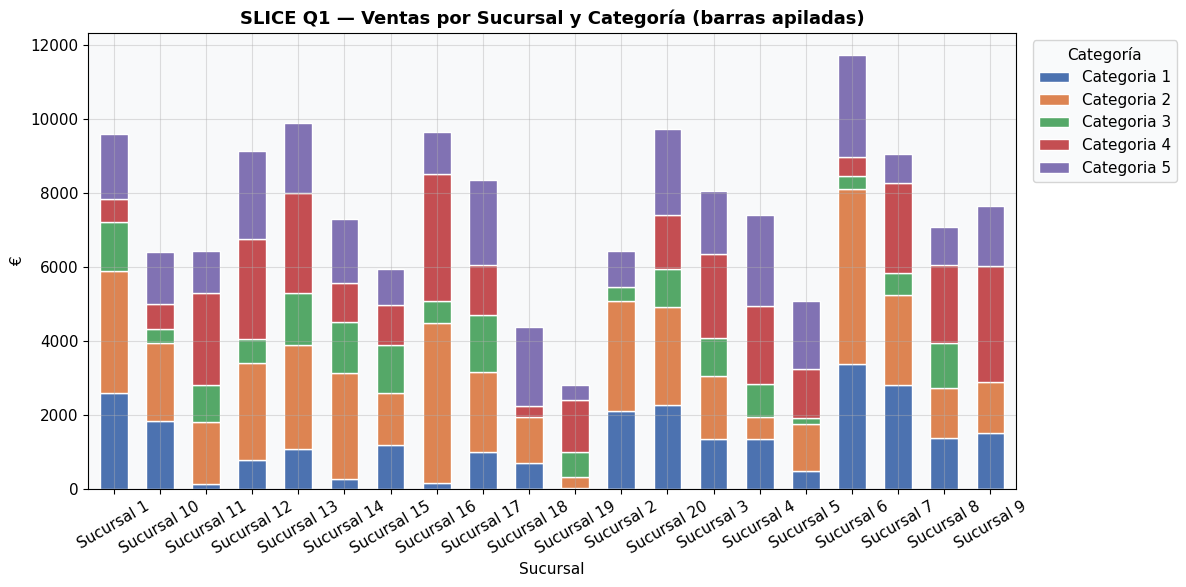

💡 Las barras apiladas muestran a la vez el total de cada sucursal y la composición por categoría — perfectas tras un slice.


In [ ]:
# ── Consulta OLAP ──
trimestre_slice = 1
ventas_slice = spark.sql(f'''
    SELECT NombreSucursal, CategoriaProducto,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas
    FROM Cubo_Ventas
    WHERE Trimestre = {trimestre_slice}
    GROUP BY NombreSucursal, CategoriaProducto
    ORDER BY NombreSucursal
''')
print(f'🔪 SLICE aplicado: Trimestre = Q{trimestre_slice}')
ventas_slice.show(20, truncate=30)

# ── Barras apiladas ──
df = ventas_slice.toPandas()
pivot = df.pivot_table(index='NombreSucursal', columns='CategoriaProducto',
                       values='TotalVentas', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, color=COLORES[:len(pivot.columns)],
           edgecolor='white', width=0.6)

ax.set_title(f'SLICE Q{trimestre_slice} — Ventas por Sucursal y Categoría (barras apiladas)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sucursal')
ax.set_ylabel('€')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Categoría', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()
print('💡 Las barras apiladas muestran a la vez el total de cada sucursal y la composición por categoría — perfectas tras un slice.')

## 🎲 Celda 9: DICE + Barras Agrupadas

**Dice** = filtramos por varias dimensiones a la vez para obtener un subcubo.

**Barras agrupadas**: cuando el dice produce datos con dos dimensiones categóricas (ej: sucursal y año), las barras agrupadas permiten **comparar simultáneamente** los grupos en cada categoría.

🎲 DICE: Categoría="Categoria 1" + Semestre 1 (Q1+Q2)
+--------------+----+-----------+
|NombreSucursal|Anio|TotalVentas|
+--------------+----+-----------+
|    Sucursal 1|2022|    6261.08|
|   Sucursal 10|2022|     2589.9|
|   Sucursal 11|2022|    4175.31|
|   Sucursal 12|2022|    2214.69|
|   Sucursal 13|2022|    3008.32|
|   Sucursal 14|2022|    1887.87|
|   Sucursal 15|2022|    2194.99|
|   Sucursal 16|2022|     314.58|
|   Sucursal 17|2022|    2492.85|
|   Sucursal 18|2022|    2550.19|
|   Sucursal 19|2022|    1354.76|
|    Sucursal 2|2022|     4495.7|
|   Sucursal 20|2022|    3396.29|
|    Sucursal 3|2022|    3074.43|
|    Sucursal 4|2022|    3644.34|
|    Sucursal 5|2022|    2328.71|
|    Sucursal 6|2022|     6275.4|
|    Sucursal 7|2022|    3898.94|
|    Sucursal 8|2022|    5899.08|
|    Sucursal 9|2022|    4004.44|
+--------------+----+-----------+



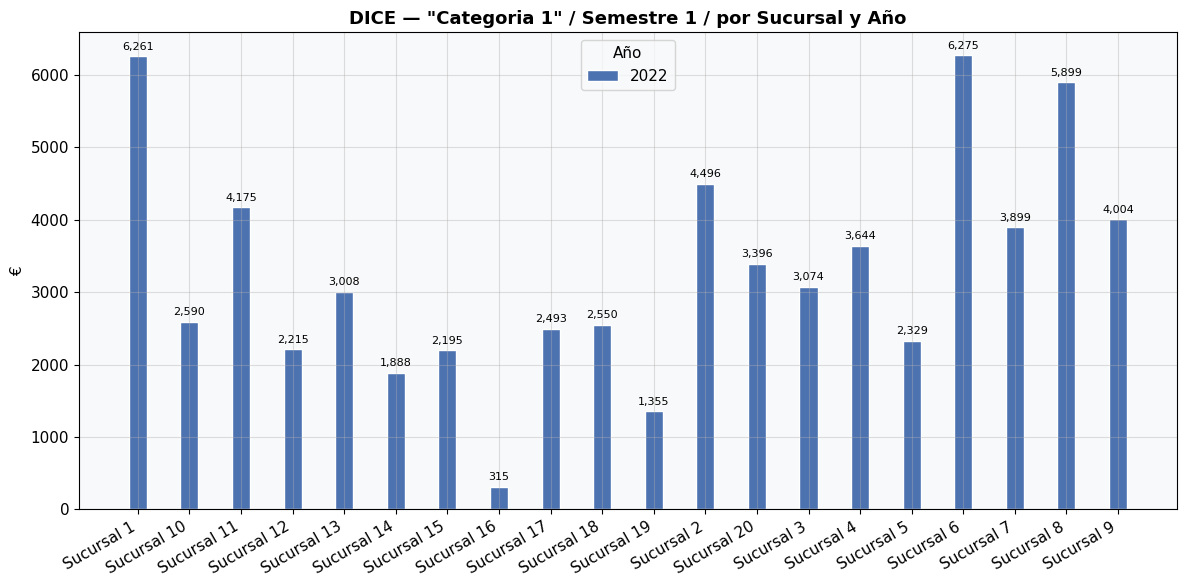

💡 Las barras agrupadas son perfectas para el dice: permiten comparar el mismo elemento (sucursal) en distintos años o periodos al mismo tiempo.


In [ ]:
# ── Consulta OLAP ──
categorias_reales = [r[0] for r in Cubo_Ventas.select('CategoriaProducto')
                     .distinct().orderBy('CategoriaProducto').collect()]
cat_dice = categorias_reales[0]

ventas_dice = spark.sql(f'''
    SELECT NombreSucursal, Anio,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas
    FROM Cubo_Ventas
    WHERE CategoriaProducto = "{cat_dice}"
    AND   Trimestre IN (1, 2)
    GROUP BY NombreSucursal, Anio
    ORDER BY NombreSucursal, Anio
''')
print(f'🎲 DICE: Categoría="{cat_dice}" + Semestre 1 (Q1+Q2)')
ventas_dice.show()

# ── Barras agrupadas ──
df    = ventas_dice.toPandas()
pivot = df.pivot_table(index='NombreSucursal', columns='Anio',
                       values='TotalVentas', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(pivot.index))
ancho = 0.35

for i, anio in enumerate(pivot.columns):
    offset = (i - len(pivot.columns)/2 + 0.5) * ancho
    bars   = ax.bar(x + offset, pivot[anio], ancho, label=str(anio),
                    color=COLORES[i], edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + max(pivot.max())*0.01,
                    f'{h:,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_title(f'DICE — "{cat_dice}" / Semestre 1 / por Sucursal y Año',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.set_ylabel('€')
ax.legend(title='Año')

plt.tight_layout()
plt.show()
print('💡 Las barras agrupadas son perfectas para el dice: permiten comparar el mismo elemento (sucursal) en distintos años o periodos al mismo tiempo.')

## 🔄 Celda 10: PIVOT + Heatmap

**Pivot** = reorganizamos los datos poniendo los valores de una dimensión como columnas (tabla cruzada).

**Heatmap (mapa de calor)**: el gráfico más natural para un pivot. La tabla cruzada tiene dos ejes (filas y columnas) y un valor numérico en cada celda. El color hace inmediatamente visible qué celdas tienen valores altos (caliente) o bajos (frío), algo imposible de ver leyendo números.

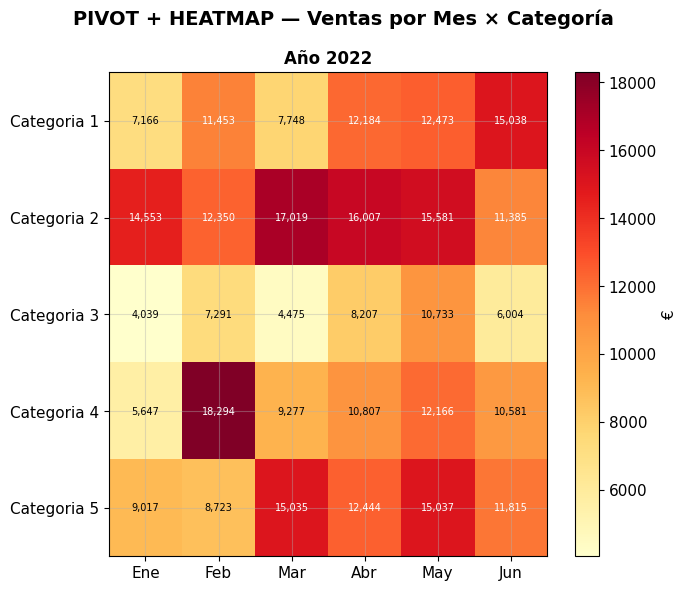

💡 El heatmap es el complemento visual perfecto del pivot: de un solo vistazo se detectan los meses y categorías con mayor y menor actividad.


In [ ]:
import matplotlib.colors as mcolors

# ── Consulta OLAP ──
ventas_pivot = spark.sql('''
    SELECT Anio, Mes, CategoriaProducto,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas
    FROM Cubo_Ventas
    GROUP BY Anio, Mes, CategoriaProducto
    ORDER BY Anio, Mes
''')

df    = ventas_pivot.toPandas()
anios = sorted(df['Anio'].unique())

meses_nombres = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                 7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

fig, axes = plt.subplots(1, len(anios), figsize=(7*len(anios), 6))
if len(anios) == 1:
    axes = [axes]
fig.suptitle('PIVOT + HEATMAP — Ventas por Mes × Categoría', fontsize=14, fontweight='bold')

for ax, anio in zip(axes, anios):
    datos = df[df['Anio'] == anio]
    pivot = datos.pivot_table(index='CategoriaProducto', columns='Mes',
                              values='TotalVentas', aggfunc='sum', fill_value=0)
    pivot.columns = [meses_nombres.get(c, c) for c in pivot.columns]

    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f'Año {anio}', fontsize=12)

    # Valores dentro de cada celda
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = 'white' if val > pivot.values.max()*0.6 else 'black'
            ax.text(j, i, f'{val:,.0f}', ha='center', va='center',
                    fontsize=7, color=color)

    plt.colorbar(im, ax=ax, label='€')

plt.tight_layout()
plt.show()
print('💡 El heatmap es el complemento visual perfecto del pivot: de un solo vistazo se detectan los meses y categorías con mayor y menor actividad.')

## 🥧 Celda 11: Cuota de Mercado + Gráfico de Tarta

**Cuota de mercado** = qué porcentaje del total representa cada dimensión (país, categoría, sucursal).

**Gráfico de tarta**: útil exclusivamente para mostrar **proporciones sobre un total**. Cuando la pregunta es "¿qué parte del pastel tiene cada uno?", la tarta es inmediata. Nota: con más de 5-6 segmentos pierde legibilidad y es mejor usar barras.

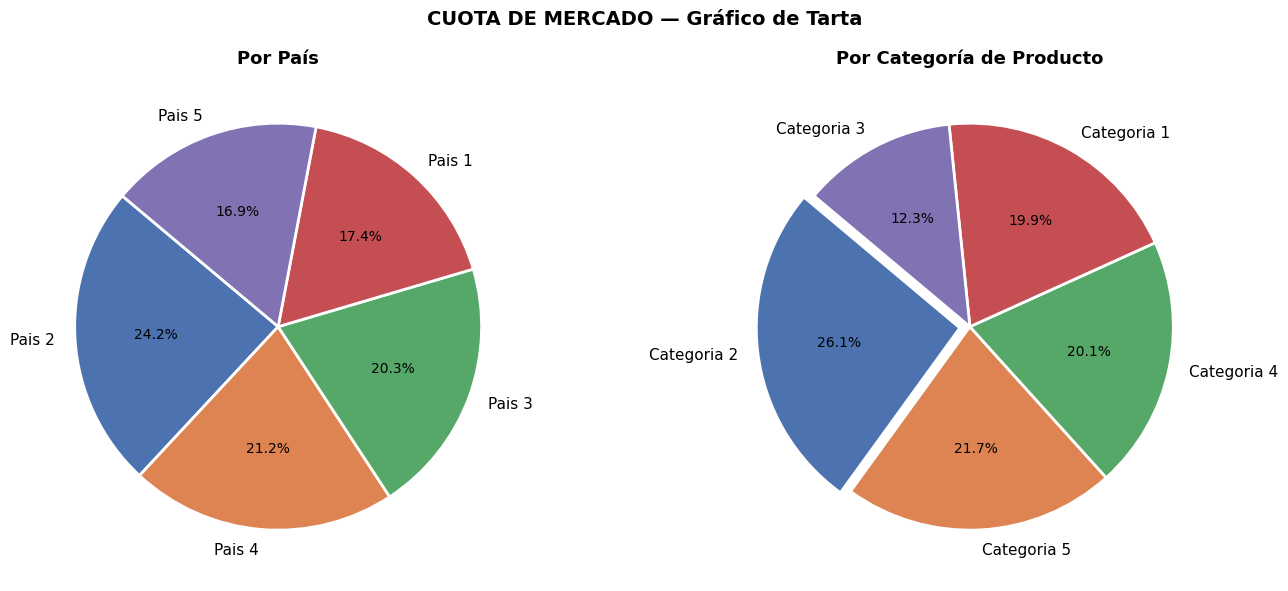

💡 La tarta es útil para proporciones (cuota de mercado). Con pocos segmentos (< 6) es muy efectiva. Con muchos segmentos, las barras horizontales son más legibles.


In [ ]:
# ── Cuota por País ──
cuota_pais = spark.sql('''
    SELECT PaisSucursal,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas
    FROM Cubo_Ventas
    GROUP BY PaisSucursal
    ORDER BY TotalVentas DESC
''').toPandas()

# ── Cuota por Categoría ──
cuota_cat = spark.sql('''
    SELECT CategoriaProducto,
           ROUND(SUM(TotalVenta), 2) AS TotalVentas
    FROM Cubo_Ventas
    GROUP BY CategoriaProducto
    ORDER BY TotalVentas DESC
''').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CUOTA DE MERCADO — Gráfico de Tarta', fontsize=14, fontweight='bold')

def autopct_fmt(pct):
    return f'{pct:.1f}%' if pct > 4 else ''

# Tarta por País
wedges, texts, autotexts = axes[0].pie(
    cuota_pais['TotalVentas'],
    labels=cuota_pais['PaisSucursal'],
    autopct=autopct_fmt,
    colors=COLORES[:len(cuota_pais)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10)
axes[0].set_title('Por País')

# Tarta por Categoría — con explode en la mayor
explode = [0.05 if i == 0 else 0 for i in range(len(cuota_cat))]
wedges2, texts2, autotexts2 = axes[1].pie(
    cuota_cat['TotalVentas'],
    labels=cuota_cat['CategoriaProducto'],
    autopct=autopct_fmt,
    colors=COLORES[:len(cuota_cat)],
    startangle=140,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts2:
    t.set_fontsize(10)
axes[1].set_title('Por Categoría de Producto')

plt.tight_layout()
plt.show()
print('💡 La tarta es útil para proporciones (cuota de mercado). Con pocos segmentos (< 6) es muy efectiva. Con muchos segmentos, las barras horizontales son más legibles.')

## 📈 Celda 12: Window Functions + Gráfico de Área

**Window Functions**: cálculos acumulados (YTD), rankings y comparativas entre periodos.

**Gráfico de área**: variante del gráfico de líneas donde el espacio bajo la curva está relleno. Es especialmente útil para **valores acumulados** (YTD) porque el área rellena representa visualmente el volumen total acumulado hasta ese punto.

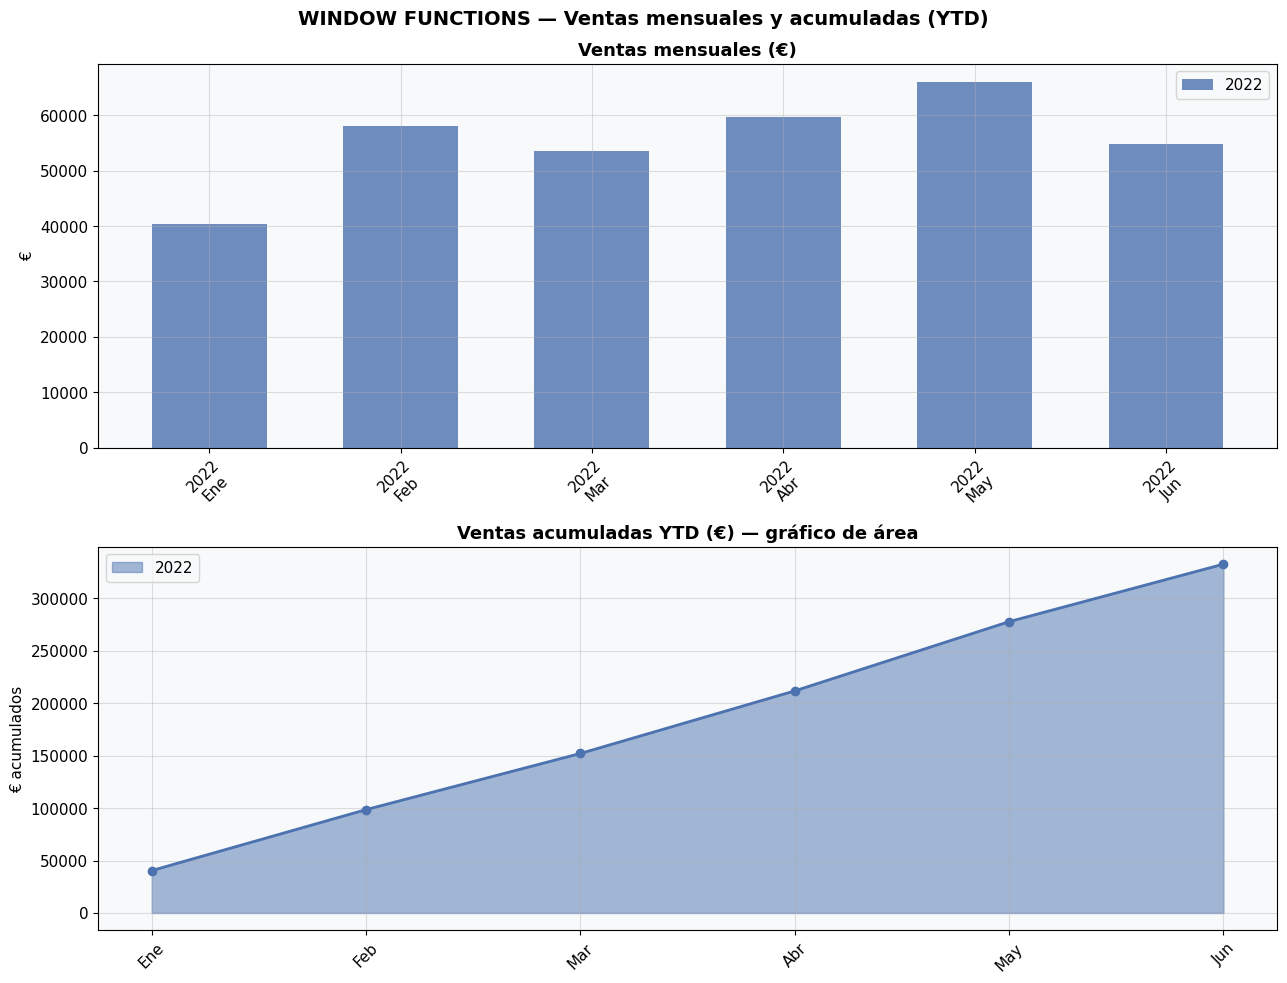


🏅 Ranking de vendedores:
+-------+-----------------------+---------+-----------+-----------+
|Ranking|         NombreVendedor|NumVentas|TotalVentas|TicketMedio|
+-------+-----------------------+---------+-----------+-----------+
|      1|  Vendedor 8 Apellido 8|       46|   14661.18|     318.72|
|      2|Vendedor 21 Apellido 21|       40|   14335.25|     358.38|
|      3|  Vendedor 5 Apellido 5|       45|   14091.33|     313.14|
|      4|Vendedor 14 Apellido 14|       39|   14024.41|      359.6|
|      5|Vendedor 19 Apellido 19|       35|   13402.18|     382.92|
|      6|  Vendedor 3 Apellido 3|       36|   13393.02|     372.03|
|      7|  Vendedor 9 Apellido 9|       38|   13365.24|     351.72|
|      8|Vendedor 28 Apellido 28|       33|   13007.03|     394.15|
|      9|Vendedor 24 Apellido 24|       35|   12069.59|     344.85|
|     10|Vendedor 13 Apellido 13|       34|   11859.51|     348.81|
|     11|Vendedor 30 Apellido 30|       30|   11647.25|     388.24|
|     12|  Vendedor 7 

In [ ]:
# ── YTD acumulado ──
ytd = spark.sql('''
    WITH ventas_mes AS (
        SELECT Anio, Mes,
               ROUND(SUM(TotalVenta), 2) AS VentasMes
        FROM Cubo_Ventas
        GROUP BY Anio, Mes
    )
    SELECT Anio, Mes, VentasMes,
           ROUND(SUM(VentasMes) OVER (
               PARTITION BY Anio ORDER BY Mes
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ), 2) AS YTD
    FROM ventas_mes
    ORDER BY Anio, Mes
''').toPandas()

anios = sorted(ytd['Anio'].unique())
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('WINDOW FUNCTIONS — Ventas mensuales y acumuladas (YTD)', fontsize=14, fontweight='bold')

alphas = [0.5, 0.3]
for i, anio in enumerate(anios):
    datos = ytd[ytd['Anio'] == anio].sort_values('Mes')
    etiq  = [meses_nombres[m-1] for m in datos['Mes']]

    # Ventas mensuales — barras
    axes[0].bar([f'{anio}\n{e}' for e in etiq], datos['VentasMes'],
                color=COLORES[i], alpha=0.8, label=str(anio), width=0.6)

    # YTD acumulado — área
    x_vals = range(len(datos))
    axes[1].fill_between(etiq, datos['YTD'], alpha=alphas[i],
                         color=COLORES[i], label=str(anio))
    axes[1].plot(etiq, datos['YTD'], color=COLORES[i],
                 linewidth=2, marker='o')

axes[0].set_title('Ventas mensuales (€)')
axes[0].set_ylabel('€')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Ventas acumuladas YTD (€) — gráfico de área')
axes[1].set_ylabel('€ acumulados')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── Ranking de vendedores ──
print('\n🏅 Ranking de vendedores:')
spark.sql('''
    SELECT RANK() OVER (ORDER BY SUM(TotalVenta) DESC) AS Ranking,
           NombreVendedor,
           COUNT(*)                   AS NumVentas,
           ROUND(SUM(TotalVenta), 2)  AS TotalVentas,
           ROUND(AVG(TotalVenta), 2)  AS TicketMedio
    FROM Cubo_Ventas
    GROUP BY NombreVendedor
    ORDER BY Ranking
''').show(truncate=30)

print('💡 El gráfico de área es perfecto para YTD: el volumen relleno bajo la curva representa visualmente el total acumulado y hace fácil comparar años.')

## 📋 Celda 13: Resumen — Qué gráfico usar con cada operación OLAP

| Operación OLAP | Gráfico recomendado | ¿Por qué? |
|----------------|--------------------|-----------|
| **Roll-up temporal** | Líneas | Muestra tendencia y evolución |
| **Drill-down** | Barras horizontales | Compara categorías entre sí |
| **Slice** | Barras apiladas | Muestra composición interna |
| **Dice** | Barras agrupadas | Compara grupos en varias dimensiones |
| **Pivot** | Heatmap | Visualiza la tabla cruzada con color |
| **Cuota de mercado** | Tarta | Proporciones sobre un total |
| **Window / YTD** | Área | Valores acumulados a lo largo del tiempo |

In [ ]:
total  = Cubo_Ventas.agg(F.round(F.sum('TotalVenta'), 2)).collect()[0][0]
uds    = Cubo_Ventas.agg(F.sum('CantidadVenta')).collect()[0][0]
trans  = Cubo_Ventas.count()

print('✅ Notebook completado.')
print(f'   Total ventas:        {total} €')
print(f'   Total unidades:      {uds}')
print(f'   Total transacciones: {trans}')
spark.stop()
print('🔴 SparkSession cerrada.')

✅ Notebook completado.
   Total ventas:        332549.64 €
   Total unidades:      5811
   Total transacciones: 1000
🔴 SparkSession cerrada.
